#프로젝트: SentencePiece 사용하기

In [1]:
!pip install konlpy
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 21.8 MB/s eta 0:00:00
Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 138 (delta 26), reused 22 (delta 8), pack-reused 91 (from 1)
Receiving objects: 100% (138/138), 1.72 MiB | 2.50 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/content/Mecab-ko-for-Google-Colab
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-01-30 08:39:09--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 13.200.41.135, 13.200.41.134, 13.200.41.136, ...
Connecting to bitbucket.org (bitbucket.org)|13.200.41.135|:443... connected.
HTTP request sent, await

##라이브러리 불러오기

In [2]:
import os
import torch
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import konlpy

%matplotlib inline

In [3]:
from konlpy.tag import Mecab

mecab = Mecab()
print(mecab.morphs('자연어처리가너무재밌어서밥먹는것도가끔까먹어요'))

['자연어', '처리', '가', '너무', '재밌', '어서', '밥', '먹', '는', '것', '도', '가끔', '까먹', '어요']


##Step 1. SentencePiece 설치하기

In [4]:
!pip install sentencepiece

##filtered_corpus 만들기

In [5]:
!wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
!tar -xzvf korean-english-park.train.tar.gz

--2026-01-30 08:41:36--  https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz [following]
--2026-01-30 08:41:37--  https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8718893 (8.3M) [application/octet-stream]
Saving to: ‘korean-english-park.train.tar.gz’

korean

In [6]:
path_to_file = "korean-english-park.train.ko"

with open(path_to_file, "r") as f:
    raw = f.read().splitlines()

print("Data Size:", len(raw))

print("Example:")
for sen in raw[0:100][::20]: print(">>", sen)

Data Size: 94123
Example:
>> 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
>> 북한의 핵무기 계획을 포기하도록 하려는 압력이 거세지고 있는 가운데, 일본과 북한의 외교관들이 외교 관계를 정상화하려는 회담을 재개했다.
>> "경호 로보트가 침입자나 화재를 탐지하기 위해서 개인적으로, 그리고 전문적으로 사용되고 있습니다."
>> 수자원부 당국은 논란이 되고 있고, 막대한 비용이 드는 이 사업에 대해 내년에 건설을 시작할 계획이다.
>> 또한 근력 운동은 활발하게 걷는 것이나 최소한 20분 동안 뛰는 것과 같은 유산소 활동에서 얻는 운동 효과를 심장과 폐에 주지 않기 때문에, 연구학자들은 근력 운동이 심장에 큰 영향을 미치는지 여부에 대해 논쟁을 해왔다.


문장의 최단 길이: 1
문장의 최장 길이: 377
문장의 평균 길이: 60


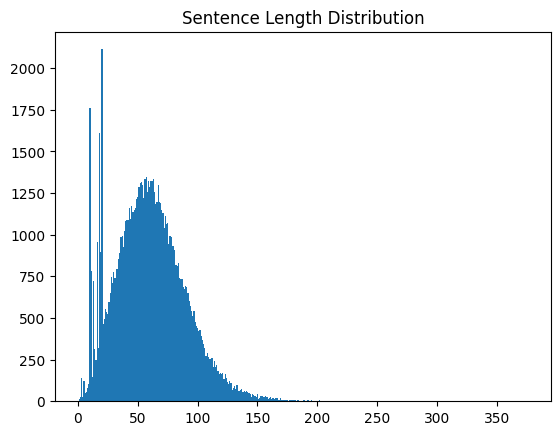

In [7]:
min_len = 999
max_len = 0
sum_len = 0

for sen in raw:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(raw))

sentence_length = np.zeros((max_len), dtype=int)

for sen in raw:
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

Data Size: 77591
문장의 최단 길이: 1
문장의 최장 길이: 377
문장의 평균 길이: 64


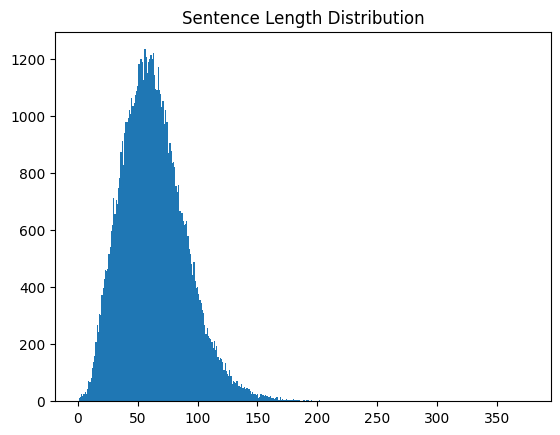

In [8]:
min_len = 999
max_len = 0
sum_len = 0

cleaned_corpus = list(set(raw))  # set를 사용해서 중복을 제거합니다.
print("Data Size:", len(cleaned_corpus))

for sen in cleaned_corpus:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(cleaned_corpus))

sentence_length = np.zeros((max_len), dtype=int)

for sen in cleaned_corpus:   # 중복이 제거된 코퍼스 기준
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

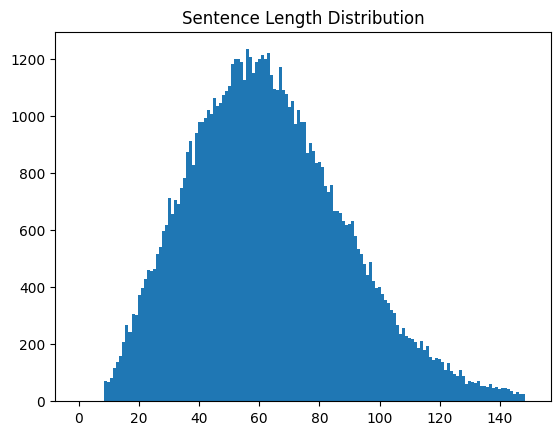

In [9]:
max_len = 150
min_len = 10

# 길이 조건에 맞는 문장만 선택합니다.
filtered_corpus = [s for s in cleaned_corpus if (len(s) < max_len) & (len(s) >= min_len)]

# 분포도를 다시 그려봅니다.
sentence_length = np.zeros((max_len), dtype=int)

for sen in filtered_corpus:
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

In [10]:
import sentencepiece as spm
temp_file = 'korean-english-park.train.ko.temp'

vocab_size = 8000

with open(temp_file, 'w') as f:
    for row in filtered_corpus:
        f.write(str(row) + '\n')

spm.SentencePieceTrainer.Train(
    '--input={} --model_prefix=korean_spm --vocab_size={}'.format(temp_file, vocab_size)
)

!ls -l korean_spm*

-rw-r--r-- 1 root root 379826 Jan 30 08:42 korean_spm.model
-rw-r--r-- 1 root root 146754 Jan 30 08:42 korean_spm.vocab


In [11]:
s = spm.SentencePieceProcessor()
s.Load('korean_spm.model')

#SentencePiece를 활용한 sentence -> encoding
tokensIDs = s.EncodeAsIds('아버지가방에들어가신다.')
print(tokensIDs)

#SentencePiece를 활용한 sentence -> encoded pieces
print(s.SampleEncodeAsPieces('아버지가방에들어가신다.',-1, 0.1))

#SentencePiece를 활용한 encoding -> sentence 복원
print(s.DecodeIds(tokensIDs))

[1246, 11, 302, 7, 3541, 11, 287, 33, 4]
['▁아버지', '가', '방', '에', '들', '어', '가', '신', '다', '.']
아버지가방에들어가신다.


##3. Tokenizer 함수 작성

In [12]:
def sp_tokenize(s, corpus):
    tensor = []

    for sen in corpus:
        tensor.append(s.EncodeAsIds(sen))

    with open("./korean_spm.vocab", 'r') as f:
        vocab = f.readlines()


    word_index = {}
    index_word = {}

    for idx, line in enumerate(vocab):
        word = line.split("\t")[0]

        word_index.update({word:idx})
        index_word.update({idx:word})

    tensor = pad_sequence(tensor, batch_first = True, padding_value = 0)

    return tensor, word_index, index_word

##Step 4. 네이버 영화리뷰 감정 분석 문제에 SentencePiece 적용해보기

###4.1 네이버 영화리뷰 데이터셋 다운로드


In [13]:
import urllib.request
import pandas as pd
from sklearn.model_selection import train_test_split

# 데이터 다운로드 (학습용, 테스트용 데이터 다운로드)
urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt", filename="ratings_train.txt") #학습용
urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt", filename="ratings_test.txt") #테스트용

# 데이터 불러오기
raw_train = pd.read_table('ratings_train.txt')
raw_test = pd.read_table('ratings_test.txt')

# raw_train을 다시 8:2로 나눠서 val_data 만들어주기
train_data, val_data = train_test_split(raw_train, test_size=0.2, random_state=42)
test_data = raw_test

print(f"전처리 전 train 데이터 개수: {len(train_data)}")
print(f"전처리 전 validation 데이터 개수: {len(val_data)}")
print(f"전처리 전 test 데이터 개수: {len(test_data)}")

전처리 전 train 데이터 개수: 120000
전처리 전 validation 데이터 개수: 30000
전처리 전 test 데이터 개수: 50000


###4.2 데이터 중복 및 결측치 제거

In [14]:
# 중복 데이터 확인 및 제거
# 'document' 컬럼을 기준으로 중복된 리뷰가 있는지 확인
train_data.drop_duplicates(subset=['document'], inplace=True)
val_data.drop_duplicates(subset=['document'], inplace=True)
test_data.drop_duplicates(subset=['document'], inplace=True)

# 결측치(Null) 제거
# 리뷰 내용이 비어있는(NaN) 행이 있는지 확인하고 제거
train_data = train_data.dropna(how='any')
val_data = val_data.dropna(how='any')
test_data = test_data.dropna(how='any')


print(f"결측치 제거 후 Train 데이터 개수: {len(train_data)}")
print(f"결측치 제거 후 Validation 데이터 개수: {len(val_data)}")
print(f"결측치 제거 후 Test 데이터 개수: {len(test_data)}")

결측치 제거 후 Train 데이터 개수: 117176
결측치 제거 후 Validation 데이터 개수: 29543
결측치 제거 후 Test 데이터 개수: 49157


###4.3 코퍼스 분석(문장길이)

문장 최대 길이: 146
문장 최소 길이: 1
문장 평균 길이: 35.92874820782413


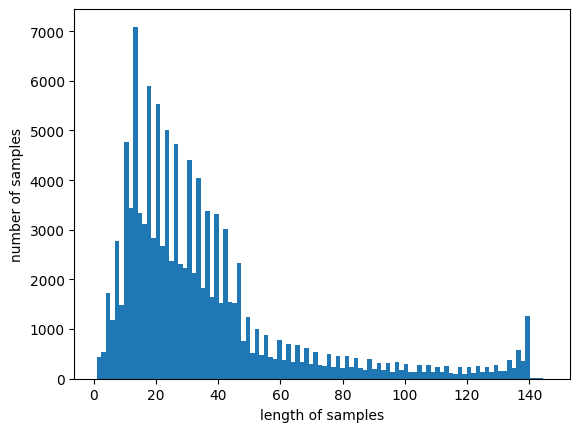

In [15]:
# 5. 문장 길이 분포 분석
# 리뷰길이를 계산하여 리스트로 저장
sentence_len = [len(str(sentence)) for sentence in train_data['document']]

print(f"문장 최대 길이: {np.max(sentence_len)}")
print(f"문장 최소 길이: {np.min(sentence_len)}")
print(f"문장 평균 길이: {np.mean(sentence_len)}")

plt.hist(sentence_len, bins=100)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

###4.4 길이기반 필터링

In [16]:
# 문장 길이 제한 설정
# 분석 결과에 따라 너무 짧거나 긴 리뷰는 제외
max_len = 140 # 위 그래프에서 볼 수 있듯이, 네이버 리뷰는 보통 140자 제한
min_len = 2   # '아', '음' 같은 너무 짧은 감탄사는 제외

# 필터링 함수 정의
def filter_corpus(data, min_len, max_len):
    # 길이를 만족하는 행만 남김
    data = data[data['document'].str.len() >= min_len]
    data = data[data['document'].str.len() <= max_len]
    return data

train_data = filter_corpus(train_data, min_len, max_len)
val_data = filter_corpus(val_data, min_len, max_len)
test_data = filter_corpus(test_data, min_len, max_len)

print(f"최종 필터링 후 train 데이터 개수: {len(train_data)}")
print(f"최종 필터링 후 validation 데이터 개수: {len(val_data)}")
print(f"최종 필터링 후 test 데이터 개수: {len(test_data)}")

최종 필터링 후 train 데이터 개수: 117049
최종 필터링 후 validation 데이터 개수: 29487
최종 필터링 후 test 데이터 개수: 49079


###4.5 SentencePiece 학습용 텍스트 파일 저장

In [17]:
# 텍스트 파일로 저장
# SentencePiece는 텍스트 파일을 입력으로 받기 때문에 파일로 내보내주기
with open('nsmc_corpus.txt', 'w', encoding='utf-8') as f:
    for line in train_data['document']:
        f.write(str(line) + '\n')

print("nsmc_corpus.txt 파일 생성 완료")

nsmc_corpus.txt 파일 생성 완료


###4.6 SentencePiece 모델 학습

In [18]:
import sentencepiece as spm

# Unigram
# vocab_size 8000 (앞 노드랑 같게)
spm.SentencePieceTrainer.Train(
    '--input=nsmc_corpus.txt --model_prefix=naver_spm_unigram --vocab_size=8000 --model_type=unigram'
)

# BPE
# 비교를 위해 BPE 방식으로도 하나 더 생성
spm.SentencePieceTrainer.Train(
    '--input=nsmc_corpus.txt --model_prefix=naver_spm_bpe --vocab_size=8000 --model_type=bpe'
)

print("Finish!")

Finish!


###4.7 학습된 모델 확인 및 테스트

In [19]:
# Unigram 모델 불러오기
s_uni = spm.SentencePieceProcessor()
s_uni.Load('naver_spm_unigram.model')

# BPE 모델 불러오기
s_bpe = spm.SentencePieceProcessor()
s_bpe.Load('naver_spm_bpe.model')

test_sentence = "코로나바이러스는 호흡기 질환입니다"

print(f"원문: {test_sentence}")
print(f"Unigram : {s_uni.encode_as_pieces(test_sentence)}")
print(f"BPE     : {s_bpe.encode_as_pieces(test_sentence)}")

원문: 코로나바이러스는 호흡기 질환입니다
Unigram : ['▁코', '로', '나', '바', '이', '러', '스', '는', '▁호흡', '기', '▁질', '환', '입니다']
BPE     : ['▁코', '로', '나', '바', '이러', '스는', '▁호', '흡', '기', '▁질', '환', '입니다']


###4.8 sp_tokenize 함수 구현

In [20]:
import torch
from torch.nn.utils.rnn import pad_sequence

def sp_tokenize(s, corpus, max_len=50):

    tensor = []

    # 문장을 숫자 ID 리스트로 변환 (Encoding)
    for sen in corpus:
        tensor.append(torch.LongTensor(s.EncodeAsIds(sen)))

    # 패딩 처리 (모든 문장의 길이를 똑같이 맞춤)
    # RNN 시퀀스 처리를 위해 pad_sequence를 사용합니다
    tensor = pad_sequence(tensor, batch_first = True, padding_value = 0)

    # 길이 조절 (너무 길면 자르고, 짧으면 0으로 채움)
    if tensor.size(1) > max_len:
        tensor = tensor[:, :max_len]
    elif tensor.size(1) < max_len:
        pad = torch.zeros(tensor.size(0), max_len - tensor.size(1), dtype=torch.long)
        tensor = torch.cat([tensor, pad], dim=1)

    # 단어 사전(Vocabulary) 정보 추출
    # 나중에 숫자를 다시 글자로 바꾸기 위해 사용
    word_index = {}
    index_word = {}

    # 모델의 전체 단어 수만큼 반복하며 사전 생성
    for idx in range(s.GetPieceSize()):
        word = s.IdToPiece(idx)
        word_index[word] = idx
        index_word[idx] = word

    return tensor, word_index, index_word

###4.9 전체 데이터셋 변환

In [21]:
# Unigram을 기준으로 데이터 변환
X_train, word_index, index_word = sp_tokenize(s_uni, train_data['document'])
X_val, _, _ = sp_tokenize(s_uni, val_data['document'])
X_test, _, _ = sp_tokenize(s_uni, test_data['document'])

# 감정 레이블(0: 부정, 1: 긍정)을 numpy 배열로 변환
y_train = train_data['label'].values
y_val = val_data['label'].values
y_test = test_data['label'].values

print(f"Train 데이터 형태: {X_train.shape}")
print(f"Validation 데이터 형태: {X_val.shape}")
print(f"Test 데이터 형태: {X_test.shape}")

Train 데이터 형태: torch.Size([117049, 50])
Validation 데이터 형태: torch.Size([29487, 50])
Test 데이터 형태: torch.Size([49079, 50])


###4.10 RNN(LSTM) 모델 설계 및 학습

In [22]:
import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(LSTMClassifier, self).__init__()
        # 1. 숫자를 의미 있는 특징(벡터)으로 변환
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # 2. 문장의 맥락(시퀀스)을 파악하는 RNN(LSTM)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        # 3. 마막지에 0(부정)인지 1(긍정)인지 결정
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        # LSTM은 마지막 글자를 읽었을 때의 기억(hidden)이 가장 중요
        _, (hidden, _) = self.lstm(x)
        # 마지막 기억을 가지고 결론도출
        x = self.fc(hidden[-1])
        return self.sigmoid(x)

###4.11 모델학습 및 평가




In [30]:
# 하이퍼파라미터 설정
#vocab_size = 8000      # 단어 사전 크기 (토큰화 단계에서 설정했던 크기)
#embedding_dim = 128    # 단어를 128차원의 벡터로 표현할 것 (숫자들의 나열 길이)
#hidden_dim = 128       # LSTM 내부 은닉층의 크기 (기억장치)
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 모델 생성 및 장치 할당
#model = LSTMClassifier(vocab_size, embedding_dim, hidden_dim).to(device)
#optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Optimizer로는 Adam 사용
#criterion = nn.BCELoss() # 이진 분류이기에 BCELoss 사용

# 데이터 형태 변환 (Tensor 변환)
# [X 데이터] 문장 인덱스 리스트 -> 정수형 텐서(LongTensor)로 변환
#X_train_tensor = torch.LongTensor(X_train).to(device)
#X_val_tensor = torch.LongTensor(X_val).to(device)
#X_test_tensor = torch.LongTensor(X_test).to(device)

# [y 데이터] 정답 레이블(0, 1) -> 실수형 텐서로 변환
# .view(-1, 1): 원래 [0, 1, 0] 형태인 1차원을 [[0], [1], [0]] 처럼 2차원 세로 기둥 모양으로 변환. 모델의 Pred와 Label의 모양을 똑같이 맞춰야 오차계산 가능
#y_train_tensor = torch.FloatTensor(y_train).view(-1, 1).to(device)
#y_val_tensor = torch.FloatTensor(y_val).view(-1, 1).to(device)
#y_test_tensor = torch.FloatTensor(y_test).view(-1, 1).to(device)

In [31]:
from torch.utils.data import DataLoader, TensorDataset

# 데이터 형태 변환 (Tensor 변환)
X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)

X_val_tensor = torch.LongTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val).view(-1, 1)

X_test_tensor = torch.LongTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

# DataLoader 설정 (데이터를 배치 단위로 쪼개기)
batch_size = 64

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size)

# 모델 및 최적화 도구 설정
model = LSTMClassifier(vocab_size, embedding_dim, hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

###4.12 모델학습 및 중간검증

In [34]:
for epoch in range(20):
    model.train()
    total_loss = 0 # 한 에폭의 평균 오차를 보기 위해 추가

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()

        # [디버깅] 전체 데이터 대신 '배치 데이터'를 모델에 넣기
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Validation
    model.eval()
    val_correct = 0
    with torch.no_grad():
        for v_batch_x, v_batch_y in val_loader:
            v_batch_x, v_batch_y = v_batch_x.to(device), v_batch_y.to(device)

            val_outputs = model(v_batch_x)
            val_predicted = (val_outputs > 0.5).float()
            val_correct += (val_predicted == v_batch_y).sum().item()

    # 최종 정확도 계산
    val_accuracy = val_correct / len(X_val_tensor)

    # 결과 출력
    print(f"Epoch {epoch+1}/20 | Loss: {total_loss/len(train_loader):.4f} | Val Accuracy: {val_accuracy * 100:.2f}%")

print("Finish!")

Epoch 1/20 | Loss: 0.5783 | Val Accuracy: 81.75%
Epoch 2/20 | Loss: 0.3533 | Val Accuracy: 84.80%
Epoch 3/20 | Loss: 0.2889 | Val Accuracy: 85.15%
Epoch 4/20 | Loss: 0.2406 | Val Accuracy: 84.95%
Epoch 5/20 | Loss: 0.1927 | Val Accuracy: 84.88%
Epoch 6/20 | Loss: 0.1462 | Val Accuracy: 84.67%
Epoch 7/20 | Loss: 0.1099 | Val Accuracy: 84.23%
Epoch 8/20 | Loss: 0.0852 | Val Accuracy: 84.05%
Epoch 9/20 | Loss: 0.0690 | Val Accuracy: 83.93%
Epoch 10/20 | Loss: 0.0585 | Val Accuracy: 83.78%
Epoch 11/20 | Loss: 0.0506 | Val Accuracy: 83.93%
Epoch 12/20 | Loss: 0.0472 | Val Accuracy: 83.53%
Epoch 13/20 | Loss: 0.0424 | Val Accuracy: 83.48%
Epoch 14/20 | Loss: 0.0393 | Val Accuracy: 84.01%
Epoch 15/20 | Loss: 0.0364 | Val Accuracy: 83.79%
Epoch 16/20 | Loss: 0.0316 | Val Accuracy: 83.70%
Epoch 17/20 | Loss: 0.0305 | Val Accuracy: 83.67%
Epoch 18/20 | Loss: 0.0285 | Val Accuracy: 83.75%
Epoch 19/20 | Loss: 0.0261 | Val Accuracy: 83.73%
Epoch 20/20 | Loss: 0.0265 | Val Accuracy: 83.67%
Finish!


###4.13 최종 성능평가

In [38]:
model.eval()
test_correct = 0

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        test_outputs = model(batch_x)
        predicted = (test_outputs > 0.5).float()

        test_correct += (predicted == batch_y).sum().item()

final_accuracy = test_correct / len(X_test_tensor)

print(f"최종 Test Accuracy: {final_accuracy * 100:.2f}%")

최종 Test Accuracy: 83.20%


###4.14 KoNLPy 형태소 분석기와의 비교 분석

In [40]:
from konlpy.tag import Okt
import numpy as np

okt = Okt()

# 형태소 분석을 통한 토큰화 수행
def tokenize_konlpy(data):
    result = []
    for sentence in data:
        # stem=True를 사용하여 '하고', '했다' 등을 '하다'로 정규화합니다
        tokens = okt.morphs(str(sentence), stem=True)
        result.append(tokens)
    return result

X_train_ko_raw = tokenize_konlpy(train_data['document'])
X_val_ko_raw = tokenize_konlpy(val_data['document'])
X_test_ko_raw = tokenize_konlpy(test_data['document'])

###4.15 정수인코딩 및 패딩

In [41]:
from collections import Counter

# 모든 단어의 빈도수 계산
all_words = [word for tokens in X_train_ko_raw for word in tokens]
word_counts = Counter(all_words)

# 특수 토큰 4개를 먼저 정의 (0, 1, 2, 3번 할당)
word_to_index = {"<PAD>": 0, "<UNK>": 1, "<BOS>": 2, "<EOS>": 3}

# 빈도수 상위 (vocab_size - 4)개 단어를 추출하여 4번 인덱스부터 추가
vocab = word_counts.most_common(vocab_size - 4)

for i, (word, _) in enumerate(vocab):
    word_to_index[word] = i + 4

# 토큰을 정수로 변환
def encode_tokens(tokenized_data, word_to_index):
    # OOV라면 1(<UNK>)을 반환
    return [[word_to_index.get(word, 1) for word in tokens] for tokens in tokenized_data]

# 변환
X_train_ko_idx = encode_tokens(X_train_ko_raw, word_to_index)
X_val_ko_idx = encode_tokens(X_val_ko_raw, word_to_index)
X_test_ko_idx = encode_tokens(X_test_ko_raw, word_to_index)

In [43]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# 1. 패딩 (모든 문장 길이를 똑같이 맞추기)
def pad_sequences_custom(data, max_len):
    padded = np.zeros((len(data), max_len), dtype=np.int64)
    for i, sentence in enumerate(data):
        length = min(len(sentence), max_len)
        padded[i, :length] = sentence[:length]
    return padded

# 아까 설정한 max_len을 사용해서 길이를 맞춰줍니다.
X_train_ko = pad_sequences_custom(X_train_ko_idx, max_len)
X_val_ko = pad_sequences_custom(X_val_ko_idx, max_len)
X_test_ko = pad_sequences_custom(X_test_ko_idx, max_len)

# 2. 데이터로더 만들기 (64개씩 쪼개 담는 그릇 정의)
# 여기서 'train_ko_loader'라는 이름이 처음으로 정의됩니다!
train_ko_loader = DataLoader(
    TensorDataset(torch.LongTensor(X_train_ko), torch.FloatTensor(y_train).view(-1, 1)),
    batch_size=64, shuffle=True
)

val_ko_loader = DataLoader(
    TensorDataset(torch.LongTensor(X_val_ko), torch.FloatTensor(y_val).view(-1, 1)),
    batch_size=64
)

test_ko_loader = DataLoader(
    TensorDataset(torch.LongTensor(X_test_ko), torch.FloatTensor(y_test).view(-1, 1)),
    batch_size=64
)

###4.16 비교군 모델 학습 및 평가

In [58]:
#Loss가 0.693에서 변화가 없어서 데이터 확인

# pre-padding으로 변경
def pad_sequences_pre(data, max_len):
    padded = np.zeros((len(data), max_len), dtype=np.int64)
    for i, sentence in enumerate(data):
        length = min(len(sentence), max_len)
        # 0을 앞에 채우고, 데이터는 뒤에 배치!
        padded[i, max_len-length:] = sentence[:length]
    return padded

X_train_ko = pad_sequences_pre(X_train_ko_idx, max_len)
X_val_ko = pad_sequences_pre(X_val_ko_idx, max_len)
X_test_ko = pad_sequences_pre(X_test_ko_idx, max_len)

print("바뀐 샘플 확인:", X_train_ko[0])

바뀐 샘플 확인: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 52  9  1 19  1]


In [54]:
# 1. 모델 초기화
model_ko = LSTMClassifier(vocab_size, embedding_dim, hidden_dim).to(device)

# 2. 옵티마이저를 RMSprop으로, 학습률은 0.001로 시도
optimizer_ko = torch.optim.RMSprop(model_ko.parameters(), lr=0.001)
criterion = nn.BCELoss()

# 3. 데이터로더 다시 정의
y_train_fixed = torch.FloatTensor(y_train).view(-1, 1)
y_val_fixed = torch.FloatTensor(y_val).view(-1, 1)

train_ko_loader = DataLoader(
    TensorDataset(torch.LongTensor(X_train_ko), y_train_fixed),
    batch_size=128,
    shuffle=True
)

val_ko_loader = DataLoader(
    TensorDataset(torch.LongTensor(X_val_ko), y_val_fixed),
    batch_size=128
)

# 학습 시작
for epoch in range(20):
    model_ko.train()
    total_loss = 0
    for batch_x, batch_y in train_ko_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer_ko.zero_grad()
        outputs = model_ko(batch_x)

        # 손실 계산
        loss = criterion(outputs, batch_y)
        loss.backward()

        optimizer_ko.step()
        total_loss += loss.item()

    # 검증
    model_ko.eval()
    val_correct = 0
    with torch.no_grad():
        for v_batch_x, v_batch_y in val_ko_loader:
            v_batch_x, v_batch_y = v_batch_x.to(device), v_batch_y.to(device)
            val_outputs = model_ko(v_batch_x)
            val_correct += ((val_outputs > 0.5).float() == v_batch_y).sum().item()

    val_acc = val_correct / len(X_val_ko)
    print(f"Epoch {epoch+1} - Loss: {total_loss/len(train_ko_loader):.4f} | Val Acc: {val_acc*100:.2f}%")

Epoch 1 - Loss: 0.4231 | Val Acc: 83.66%
Epoch 2 - Loss: 0.3243 | Val Acc: 84.69%
Epoch 3 - Loss: 0.2804 | Val Acc: 86.02%
Epoch 4 - Loss: 0.2435 | Val Acc: 85.77%
Epoch 5 - Loss: 0.2072 | Val Acc: 85.79%
Epoch 6 - Loss: 0.1708 | Val Acc: 85.61%
Epoch 7 - Loss: 0.1364 | Val Acc: 85.32%
Epoch 8 - Loss: 0.1052 | Val Acc: 85.07%
Epoch 9 - Loss: 0.0816 | Val Acc: 84.67%
Epoch 10 - Loss: 0.0624 | Val Acc: 84.84%
Epoch 11 - Loss: 0.0491 | Val Acc: 84.44%
Epoch 12 - Loss: 0.0385 | Val Acc: 84.73%
Epoch 13 - Loss: 0.0344 | Val Acc: 84.58%
Epoch 14 - Loss: 0.0284 | Val Acc: 84.69%
Epoch 15 - Loss: 0.0244 | Val Acc: 84.91%
Epoch 16 - Loss: 0.0224 | Val Acc: 84.62%
Epoch 17 - Loss: 0.0207 | Val Acc: 84.57%
Epoch 18 - Loss: 0.0191 | Val Acc: 84.39%
Epoch 19 - Loss: 0.0176 | Val Acc: 84.72%
Epoch 20 - Loss: 0.0160 | Val Acc: 84.57%


pre로 데이터를 바꿔줬음에도변화가 없어서 shape을 코드를 다시 확인하던 중 shape이 안맞는 문제를 발견.

label과 pred의 shape 안 맞아서 학습이 아예 안됐는데,

view(-1, 1)로 shape을 강제로 맞춰주니학습이 **되었음**

In [56]:
test_ko_loader = DataLoader(
    TensorDataset(torch.LongTensor(X_test_ko), torch.FloatTensor(y_test).view(-1, 1)),
    batch_size=128
)

# 최종 테스트
model_ko.eval()
test_ko_correct = 0

with torch.no_grad():
    for batch_x, batch_y in test_ko_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        test_outputs = model_ko(batch_x)

        # [디버깅] test할 때 shape을 맞춰주기
        # predicted와 batch_y의 shape이 둘 다 [128, 1]이어야 정확히 채점
        predicted = (test_outputs > 0.5).float()
        test_ko_correct += (predicted == batch_y).sum().item()

# 전체 맞춘 개수 계산
final_ko_acc = test_ko_correct / len(X_test_ko)

print(f"최종 KoNLPy 최종 점수: {final_ko_acc * 100:.2f}%")

최종 KoNLPy 최종 점수: 84.05%
